<a href="https://colab.research.google.com/github/Payal-20-06/Sales-Data-Analysis-Project/blob/main/project2_course.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Mini Project 2: Advanced Sales Data Analysis
🎯 Objective
Build a Python project using:
1.  Lists, Dictionaries
2. NumPy
3. Pandas
4. Data Visualization



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/sales_data_sample.csv")

In [ ]:

# Generate sample data
np.random.seed(42)
num_rows = 100

data = {
    'order_year': np.random.choice([2021, 2022, 2023], num_rows),
    'order_month': np.random.randint(1, 13, num_rows),
    'total_revenue': np.random.uniform(100, 5000, num_rows).round(2),
    'total_orders': np.random.randint(1, 50, num_rows)
}

sample_df = pd.DataFrame(data)

# Save the sample data to the CSV file
sample_df.to_csv('/content/sales_data_sample.csv', index=False)

print("Sample data generated and saved to /content/sales_data_sample.csv")

Sample data generated and saved to /content/sales_data_sample.csv


Now that we have sample data in `sales_data_sample.csv`, let's reload the DataFrame, perform the necessary data type conversions, and then create the bar plot for yearly revenue.


* Reload the DataFrame with the newly generated data
* Convert to numeric
* Remove missing values




In [ ]:
# Reload the DataFrame with the newly generated data
df = pd.read_csv("/content/sales_data_sample.csv")

# Convert to numeric (important fix)
df["total_revenue"] = pd.to_numeric(df["total_revenue"], errors='coerce')
df["total_orders"] = pd.to_numeric(df["total_orders"], errors='coerce')

In [ ]:
print(df.head())
print(df.columns)

   order_year  order_month  total_revenue  total_orders
0        2023           12        3544.79            35
1        2021            8        1881.79            49
2        2023            8        4861.73            17
3        2023           11        4815.99            44
4        2021            3        1333.73            28
Index(['order_year', 'order_month', 'total_revenue', 'total_orders'], dtype='object')


In [ ]:
df.columns = df.columns.str.strip()
print(df.isnull().sum())

order_year       0
order_month      0
total_revenue    0
total_orders     0
dtype: int64


In [ ]:
df = df.dropna()

# 🔹 STEP 4: Basic Analysis


In [ ]:
print("Total Revenue:", df["total_revenue"].sum())
print("Average Revenue:", df["total_revenue"].mean())
print("Total Orders:", df["total_orders"].sum())

Total Revenue: 251589.92
Average Revenue: 2515.8992000000003
Total Orders: 2789


# 🔹 STEP 5: Feature Engineering (IMPORTANT)

In [ ]:
df["revenue_per_order"] = df["total_revenue"] / df["total_orders"]

# 🔹 STEP 6: Year-wise Analysis

In [ ]:
yearly_sales = df.groupby("order_year")["total_revenue"].sum()
print("\nYearly Sales:\n", yearly_sales)


Yearly Sales:
 order_year
2021    77615.01
2022    91307.89
2023    82667.02
Name: total_revenue, dtype: float64


# 🔹 STEP 7: Month-wise Analysis

In [ ]:
monthly_sales = df.groupby("order_month")["total_revenue"].sum()
print("\nMonthly Sales:\n", monthly_sales)


Monthly Sales:
 order_month
1     26227.02
2      5185.81
3     17613.79
4     12165.07
5     13289.30
6     15052.21
7     40395.12
8     21872.07
9     18508.38
10    20109.51
11    24871.55
12    36300.09
Name: total_revenue, dtype: float64


# 🔹 STEP 8: Visualization


# 📊 Yearly Revenue Bar Chart

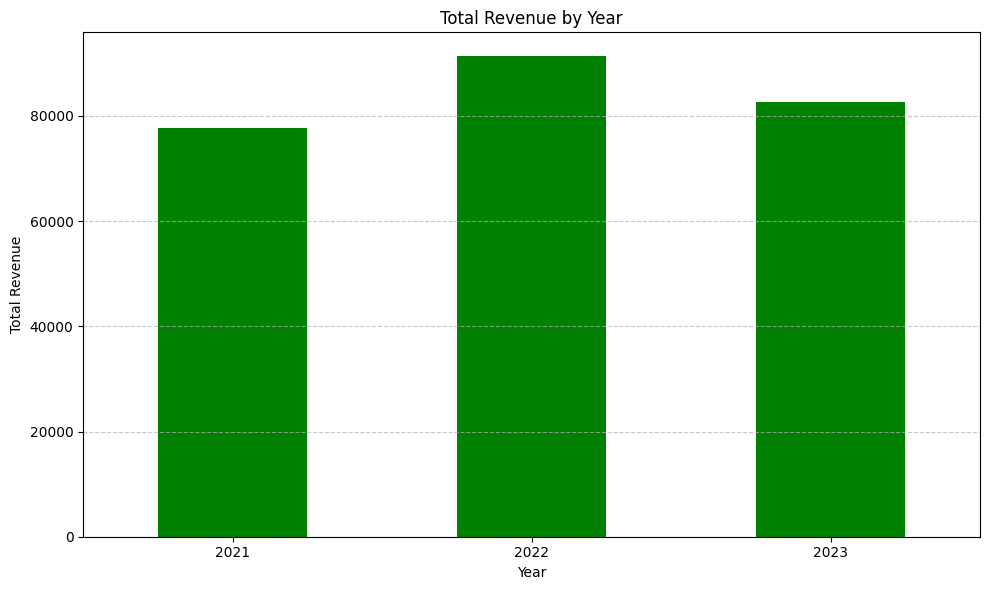

In [ ]:
# Plot the yearly revenue
plt.figure(figsize=(10, 6))
yearly_sales.plot(kind='bar', color='Green')
plt.title("Total Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 📈 Monthly Revenue Trend

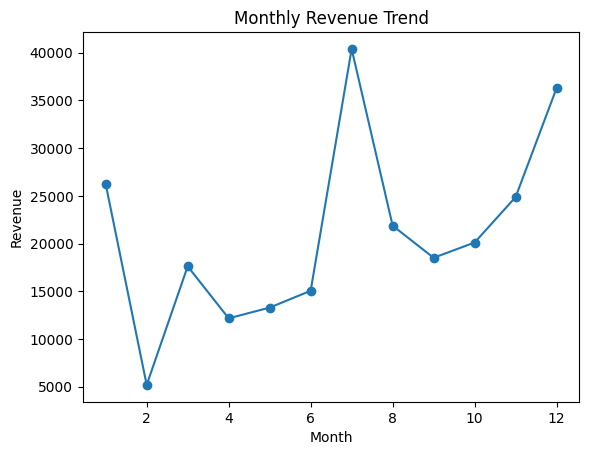

In [ ]:

plt.figure()
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

# 🔥 Correlation Heatma

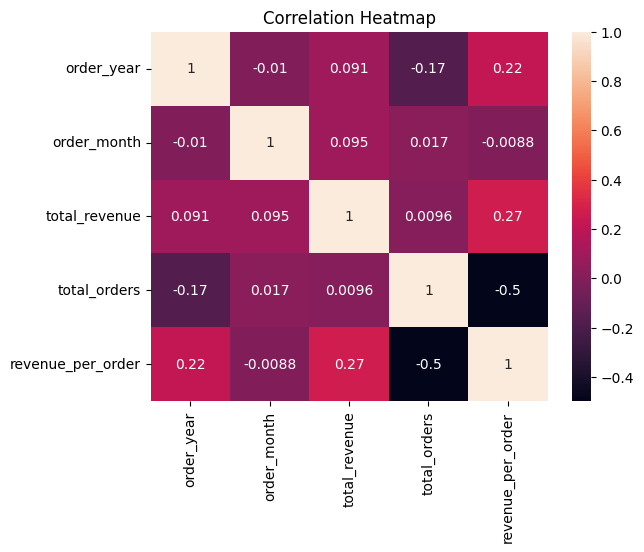

In [ ]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# 🔹 STEP 9: Insights (PRINT)

In [ ]:
print("\n--- Insights ---")


--- Insights ---


In [ ]:
print("Highest Revenue Year:", yearly_sales.idxmax())
print("Highest Revenue Month:", monthly_sales.idxmax())

Highest Revenue Year: 2022
Highest Revenue Month: 7


In [ ]:
correlation = df["total_revenue"].corr(df["total_orders"])
print("Correlation between Orders & Revenue:", correlation)

Correlation between Orders & Revenue: 0.009625507087789132


In [ ]:

import calendar
df["month_name"] = df["order_month"].apply(lambda x: calendar.month_name[int(x)])

In [ ]:
pip install pandasql

In [ ]:
from pandasql import sqldf

In [ ]:
# Total Revenue
total_revenue_query = "SELECT SUM(total_revenue) FROM df;"
total_revenue_result = sqldf(total_revenue_query, {'df': df})
print("\nTotal Revenue:\n", total_revenue_result)

# Revenue by Year
revenue_by_year_query = "SELECT order_year, SUM(total_revenue) AS total_revenue FROM df GROUP BY order_year;"
revenue_by_year_result = sqldf(revenue_by_year_query, {'df': df})
print("\nRevenue by Year:\n", revenue_by_year_result)

# Top Month
top_month_query = "SELECT order_month, SUM(total_revenue) AS total_revenue FROM df GROUP BY order_month ORDER BY SUM(total_revenue) DESC;"
top_month_result = sqldf(top_month_query, {'df': df})
print("\nTop Month:\n", top_month_result)


Total Revenue:
    SUM(total_revenue)
0           251589.92

Revenue by Year:
    order_year  total_revenue
0        2021       77615.01
1        2022       91307.89
2        2023       82667.02

Top Month:
     order_month  total_revenue
0             7       40395.12
1            12       36300.09
2             1       26227.02
3            11       24871.55
4             8       21872.07
5            10       20109.51
6             9       18508.38
7             3       17613.79
8             6       15052.21
9             5       13289.30
10            4       12165.07
11            2        5185.81


In [ ]:


print("Mean Revenue:", np.mean(df["total_revenue"]))
print("Median Revenue:", np.median(df["total_revenue"]))
print("Standard Deviation:", np.std(df["total_revenue"]))


Mean Revenue: 2515.8992000000003
Median Revenue: 2652.275
Standard Deviation: 1388.911612183209


In [ ]:
import plotly.express as px

fig = px.line(df, x="order_month", y="total_revenue", title="Monthly Revenue Trend")
fig.show()